In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb 

In [3]:
import os
os.getcwd()

'/Users/zakariaabdullahi/Documents/crypto-dashboard-DE25-UX25/eda'

In [4]:
df = pd.read_csv("../data/interim/master_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

 ## EDA 1 
 - Volitilaty: Mesauring the how the prise sways daily.
High Volitilaty = High Risk

In [15]:
# EDA 1
# Standard Deviation of daily returns as a measure of thee volatility
vol = (
    df.groupby("coin_id")["daily_return_pct"]
    .std()
    .reset_index()
    .sort_values("daily_return_pct", ascending=False)
)
vol.index = vol.index + 1

vol



,coin_id,daily_return_pct
2,dogwifcoin,6.726459
3,floki,5.820928
4,official-trump,5.326817
1,bitcoin,2.308453


## EDA 2 

As we can see the Meme coins rise faster in the short term, but then they struggle to hold that price.
But on the other hand Bitcoin shows better development in the long term.

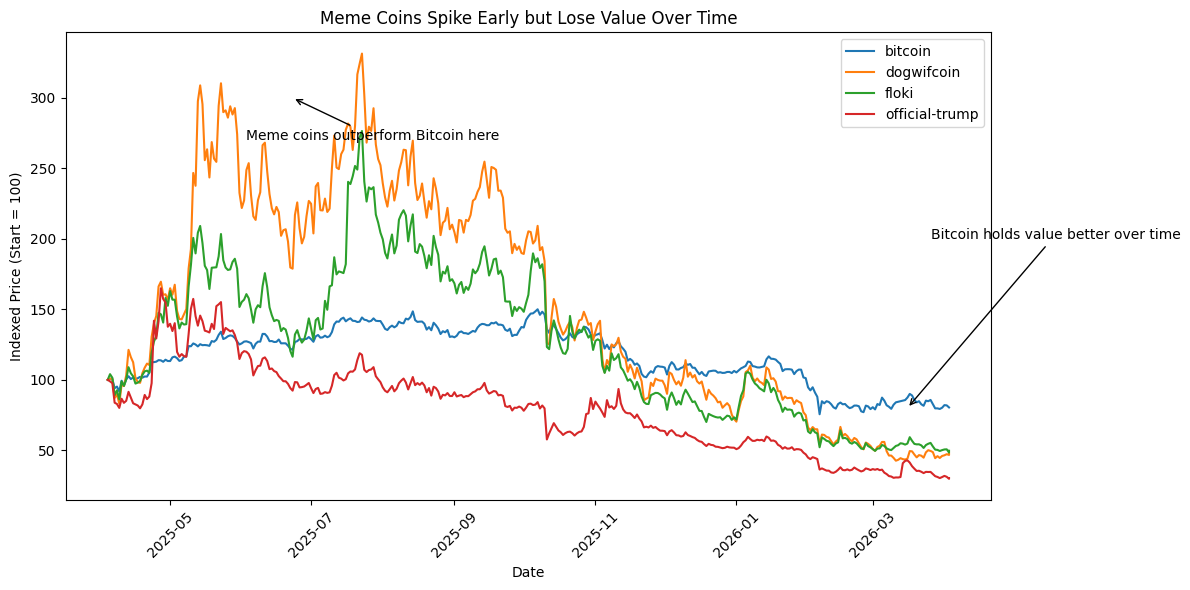

In [ ]:
# sorting the data 
df = df.sort_values(["coin_id", "date"])

#  index price (start = 100)
df["price_index"] = df.groupby("coin_id")["price"].transform(
    lambda s: (s / s.iloc[0]) * 100
)

# plot
plt.figure(figsize=(12, 6))

for coin in df["coin_id"].unique():
    coin_df = df[df["coin_id"] == coin]
    plt.plot(coin_df["date"], coin_df["price_index"], label=coin)

plt.title("Meme Coins Spike Early but Lose Value Over Time")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.xticks(rotation=45)

# Storytelling annotationing
plt.annotate(
    "Meme coins outperform Bitcoin here",
    xy=(df["date"].iloc[80], 300),
    xytext=(df["date"].iloc[60], 270),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# storytelling annotation 
plt.annotate(
    "Bitcoin holds value better over time",
    xy=(df["date"].iloc[-20], 80),
    xytext=(df["date"].iloc[-10], 200),  
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.tight_layout()
plt.show()

## EDA 3 
### Average return 


In [14]:
avg_return = (
    df.groupby("coin_id")["daily_return_pct"]
    .mean()
    .reset_index()
    .sort_values("daily_return_pct", ascending=False)
    .reset_index(drop=True)
)
avg_return.index = avg_return.index + 1
avg_return


,coin_id,daily_return_pct
1,dogwifcoin,0.020092
2,floki,-0.024676
3,bitcoin,-0.033072
4,official-trump,-0.191905


## EDA 4